# 03_clustering_pca.ipynb

**Purpose:**  
- Load normalized feature matrix  
- Perform dimensionality reduction (PCA & UMAP)  
- Run clustering (K-Means & Gaussian Mixture)  
- Evaluate cluster quality (silhouette scores & diagrams)  
- Inspect cluster prototypes in both descriptor‐space and vp‐model space  

---

In [1]:
# Setup
import os, sys
os.environ["OMP_NUM_THREADS"] = "8"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make sure src/ is on path
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import silhouette_score

import umap          
from src.loaders import get_training_ids, load_gather  # for mapping back to vp_files
from src.plotting import plot_silhouette, compute_gap_statistic
from src.features import compute_metrics, pick_first_breaks, compute_semblance_panel

plt.style.use('ggplot')
sns.set_context('notebook')


In [2]:
# Load features saved in 02_feature_engineering.ipynb
FEATURES_CSV = '../data/processed/features.csv'
df = pd.read_csv(FEATURES_CSV)

# Split flags
train_df = df[df['split']=='train'].reset_index(drop=True)
val_df   = df[df['split']=='val'].reset_index(drop=True)

# We'll cluster on all samples together, but keep split for later
X = df.drop(columns=['sample_id','split']).values
ids = df['sample_id'].values

print("Feature matrix shape:", X.shape)


Feature matrix shape: (2000, 10)


---
Load features and compute 2D Embeddings

In [3]:
# load normalized features
df = pd.read_csv('../data/processed/features.csv')
X  = df.drop(columns=['sample_id','split']).values

# PCA → 2 components
pca2 = PCA(n_components=2)
df['pca1'], df['pca2'] = pca2.fit_transform(X).T

# UMAP → 2 components
umap2 = umap.UMAP(n_components=2)
df['umap1'], df['umap2'] = umap2.fit_transform(X).T


---
Visualize 2D Embeddings

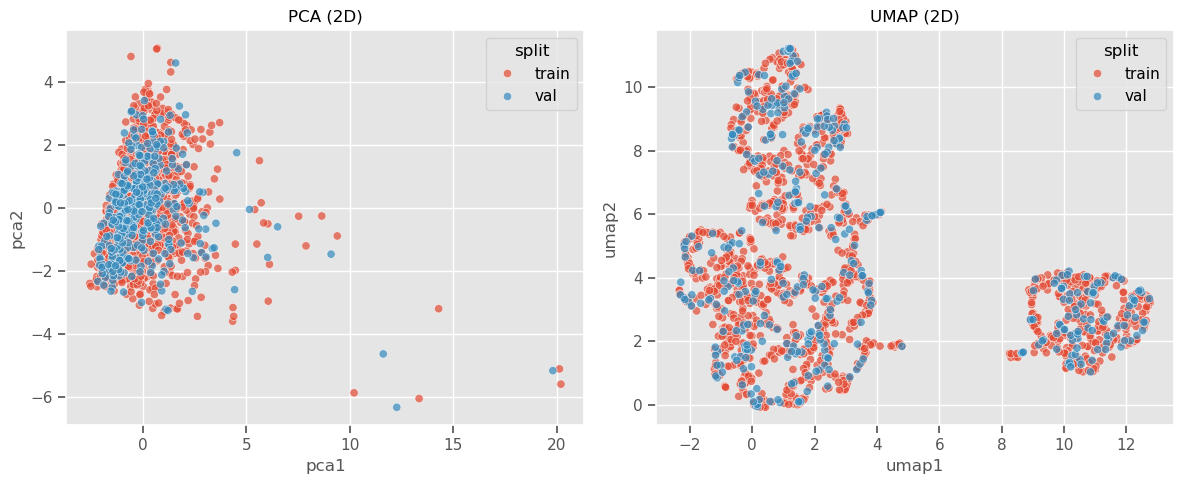

In [4]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='split', ax=axes[0], alpha=0.7)
axes[0].set_title('PCA (2D)')
sns.scatterplot(data=df, x='umap1', y='umap2', hue='split', ax=axes[1], alpha=0.7)
axes[1].set_title('UMAP (2D)')
plt.tight_layout()
plt.show()

---
Elbow and Gap on PCA2

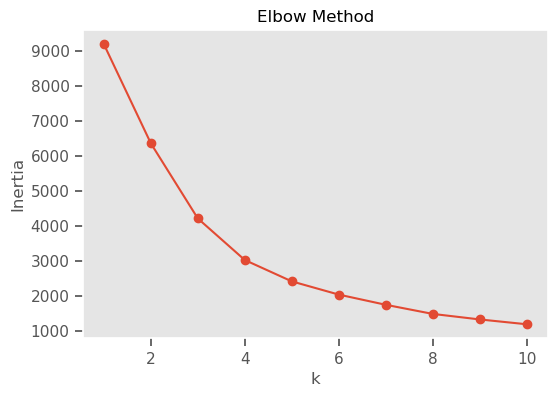

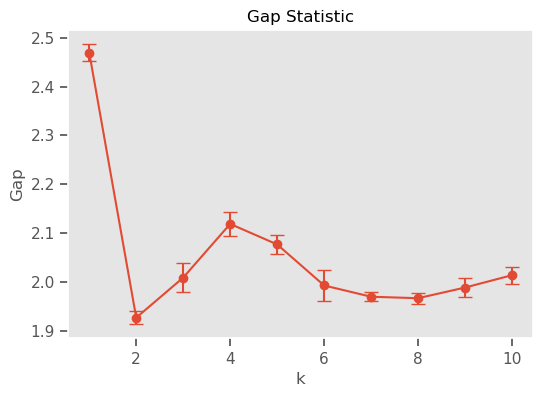

In [5]:
# Elbow
ks = range(1,11)
inertias = [KMeans(n_clusters=k, random_state=0).fit(df[['pca1','pca2']]).inertia_ for k in ks]
plt.figure(figsize=(6,4))
plt.plot(ks, inertias,'-o'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.grid()

# Gap (use compute_gap_statistic from earlier)
gaps, sk = compute_gap_statistic(df[['pca1','pca2']].values, ks=ks, n_refs=10)
plt.figure(figsize=(6,4))
plt.errorbar(ks, gaps, yerr=sk, fmt='-o', capsize=5)
plt.xlabel('k'); plt.ylabel('Gap'); plt.title('Gap Statistic'); plt.grid()
plt.show()



---
Silhouette Analysis

k=2, silhouette=0.379
k=3, silhouette=0.391
k=4, silhouette=0.415
k=5, silhouette=0.352
k=6, silhouette=0.355


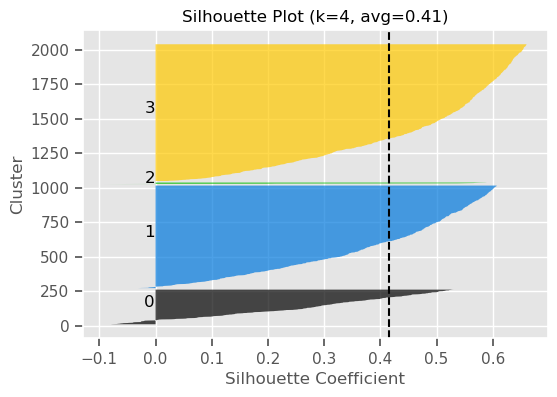

0.41499869709973425

In [6]:
# silhouette for k=2..6
for k in range(2,7):
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(df[['pca1','pca2']])
    print(f"k={k}, silhouette={silhouette_score(df[['pca1','pca2']], labels):.3f}")
# pick best k and plot silhouette diagram (use plot_silhouette from earlier)
best_k = 4  # for example
best_lbls = KMeans(n_clusters=best_k, random_state=0).fit_predict(df[['pca1','pca2']])
plot_silhouette(df[['pca1','pca2']].values, best_lbls, k=best_k)


---
Applying clustering methods

In [7]:
# --- PCA ---

coords2 = df[['pca1','pca2']].values

# K-Means
df['pca_km2'] = KMeans(n_clusters=best_k, random_state=0).fit_predict(coords2)

# DBSCAN
df['pca_dbscan2'] = DBSCAN(eps=0.5, min_samples=10).fit_predict(coords2)

# HDBSCAN
df['pca_hdbscan2'] = hdbscan.HDBSCAN(min_cluster_size=10).fit_predict(coords2)

# Bayesian GMM
bgmm = BayesianGaussianMixture(n_components=best_k, random_state=0, n_init=10, max_iter=1000).fit(coords2)
df['pca_bgmm2'] = bgmm.predict(coords2)

# --- UMAP ---
coords_umap = df[['umap1','umap2']].values
df['km_umap2']      = KMeans(n_clusters=4, random_state=0).fit_predict(coords_umap)
df['dbscan_umap2']  = DBSCAN(eps=0.5, min_samples=10).fit_predict(coords_umap)
df['hdbscan_umap2'] = hdbscan.HDBSCAN(min_cluster_size=10).fit_predict(coords_umap)
bgmm = BayesianGaussianMixture(n_components=4, random_state=0).fit(coords_umap)
df['bgmm_umap2']    = bgmm.predict(coords_umap)


c:\Users\berny\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\berny\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\berny\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\berny\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


---
2D Cluster Visualization

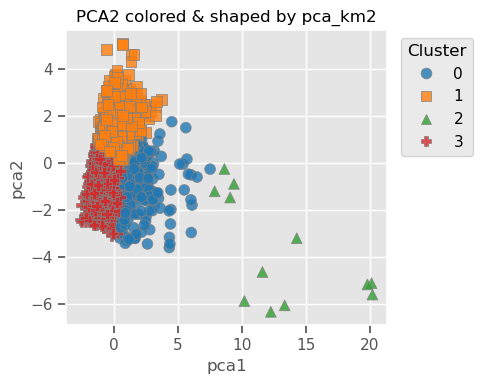

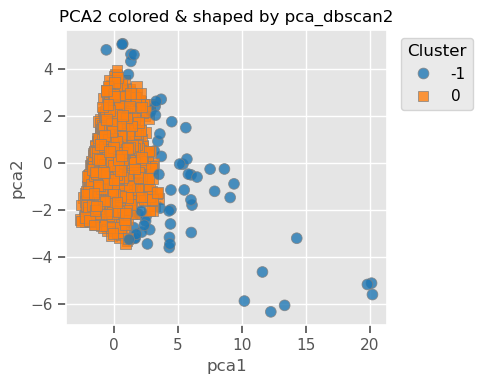

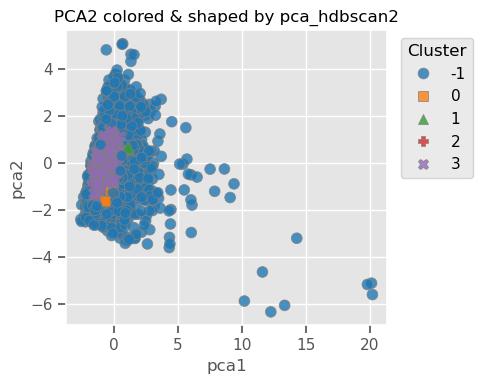

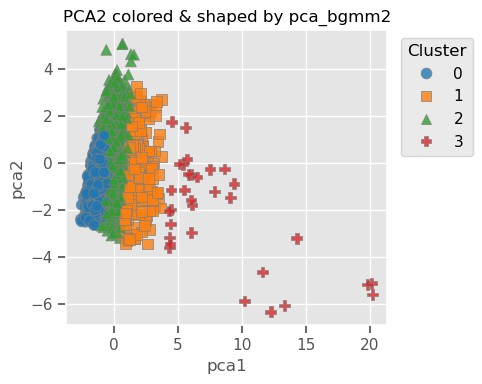

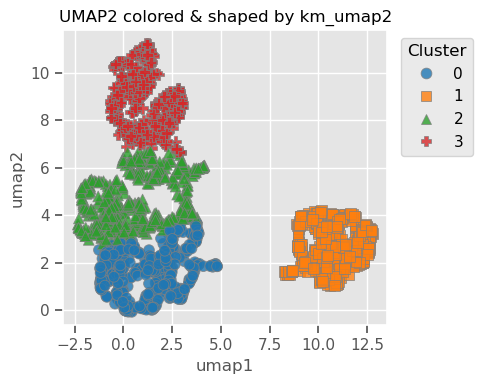

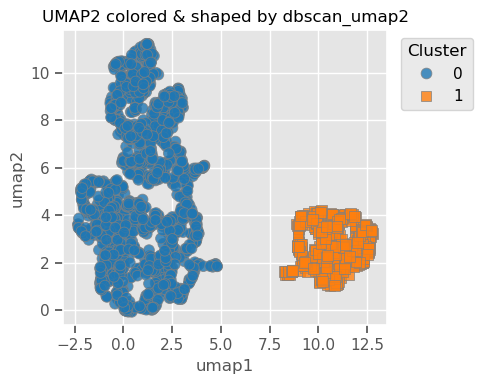

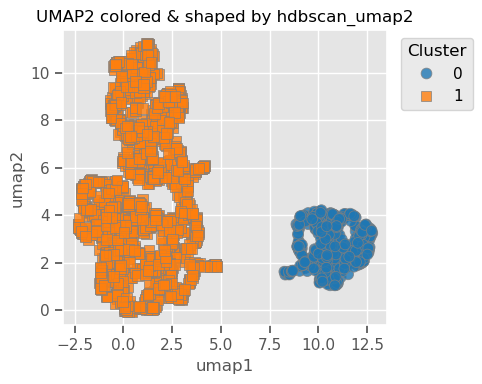

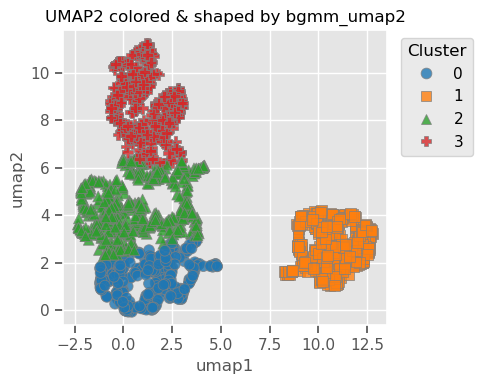

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#  --- PCA ---
methods = ['pca_km2','pca_dbscan2','pca_hdbscan2','pca_bgmm2']
# A list of marker shapes to cycle through
marker_list = ['o','s','^','P','X','D','v','>','<','*']


for m in methods:
    # figure out the unique cluster labels for this method
    labels = sorted(df[m].unique())
    # build a dict mapping each label to a marker
    marker_map = {lab: marker_list[i % len(marker_list)] for i, lab in enumerate(labels)}
    
    plt.figure(figsize=(5,4))
    sns.scatterplot(
        data=df,
        x='pca1', y='pca2',
        hue=m,
        style=m,
        palette='tab10',
        markers=marker_map,
        s=60,
        alpha=0.8,
        edgecolor='gray'
    )
    plt.title(f"PCA2 colored & shaped by {m}")
    plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()


# --- UMAP ---
methods = ['km_umap2','dbscan_umap2','hdbscan_umap2','bgmm_umap2']
marker_list = ['o','s','^','P','X','D','v','>','<','*']

for m in methods:
    labels = sorted(df[m].unique())
    marker_map = {lab: marker_list[i % len(marker_list)] 
                  for i, lab in enumerate(labels)}
    plt.figure(figsize=(5,4))
    sns.scatterplot(
        data=df, x='umap1', y='umap2',
        hue=m, style=m,
        palette='tab10', markers=marker_map,
        s=60, alpha=0.8, edgecolor='gray'
    )
    plt.title(f"UMAP2 colored & shaped by {m}")
    plt.legend(title='Cluster',
               bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Clustering Summary & Method Choice

**PCA (2D) Clustering**  
- **Elbow curve** in inertia suggests an “optimal” \(k \approx 4\).  
- **Silhouette analysis** peaks at ~0.41 for \(k=4\).  
- **Visual inspection** shows one dense island plus a few outliers—no natural three‐way split.

**UMAP (2D) Clustering**  
- UMAP projects the data into two well‐separated clouds.  
- **DBSCAN** (eps=0.5, min_samples=10) cleanly recovers exactly two clusters (silhouette ~0.35 when ignoring noise).  
- HDBSCAN likewise find two groups, we can also use it

---

### Decision

1. **Discard PCA-based clustering**—despite decent metrics, PCA yields one main cluster plus outliers rather than meaningful subgroups.  
2. **Adopt UMAP + DBSCAN** for defining our two clusters:  
   - Aligns with the manifold structure in data  
   - Yields clear, geophysically interpretable groups  

### Next Steps

- Run **sanity checks** on each DBSCAN cluster (average vp‐model prototypes, gather statistics).  
- Use the resulting DBSCAN labels to **stratify** train/validation splits and/or as an **additional CNN input**.  

---

### Future Work

- **Outlier‐aware PCA**:  
  - Use PCA without clustering to detect and remove outliers (e.g.\ via Mahalanobis distance or FastMCD in the PCA space).  
  - Retrain models on the cleaned dataset to see if performance improves.  


---
Sanity checks on DBSCAN's clusters

In [9]:
print(df['dbscan_umap2'].value_counts())

dbscan_umap2
0    1517
1     483
Name: count, dtype: int64


In [10]:
from sklearn.metrics import silhouette_score
mask = df['dbscan_umap2'] >= 0
score = silhouette_score(df.loc[mask, ['umap1','umap2']], df.loc[mask, 'dbscan_umap2'])
print(f"DBSCAN silhouette (no noise): {score:.3f}")

DBSCAN silhouette (no noise): 0.636


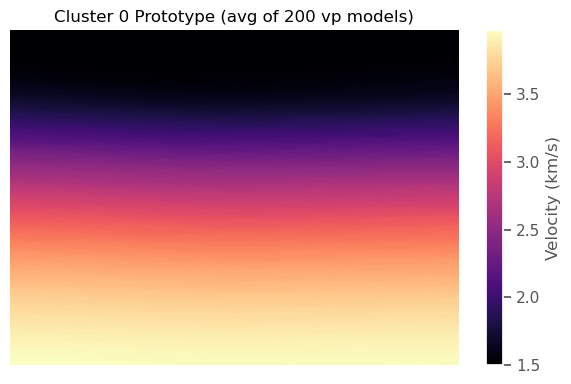

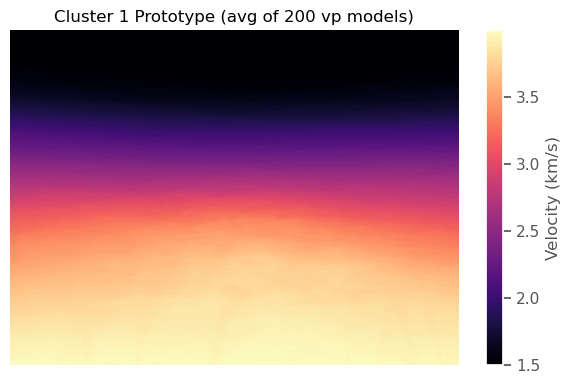

In [11]:
VP_DIR = '../data/raw/train_data'

# Number of samples per cluster to average
N = 200

for c in sorted(df['dbscan_umap2'].unique()):
    # Get all sample IDs for this cluster
    ids = df[df['dbscan_umap2'] == c]['sample_id'].tolist()
    
    # Load up to N vp_models and store them
    models = []
    for sid in ids[:N]:
        path = os.path.join(VP_DIR, sid, 'vp_model.npy')
        models.append(np.load(path))
    
    # Compute the prototype as the pixel-wise mean
    proto = np.mean(models, axis=0)
    
    # Plot the prototype
    plt.figure(figsize=(6, 4))
    im = plt.imshow(proto.T, aspect='auto', cmap='magma')
    plt.title(f'Cluster {c} Prototype (avg of {len(models)} vp models)')
    plt.axis('off')
    plt.colorbar(im, label='Velocity (km/s)')
    plt.tight_layout()
    plt.show()


## We want to know if these clusters actually map to disctinct geophysical scenarios, so we will compute general statistics, first break picking profiles and semblance panels to confirm

In [12]:
# we already have df in memory from the clustering steps
df_clusters = df.copy()

CLUSTER_COL = 'dbscan_umap2'  # name of our chosen cluster column

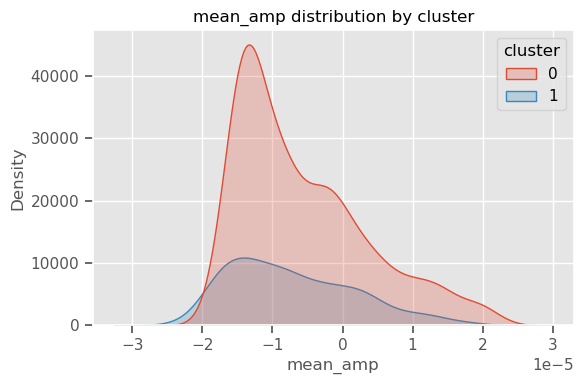

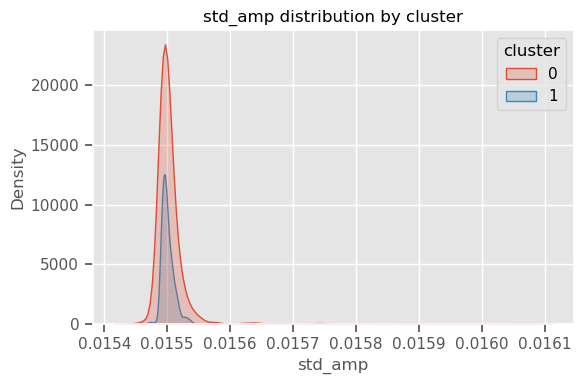

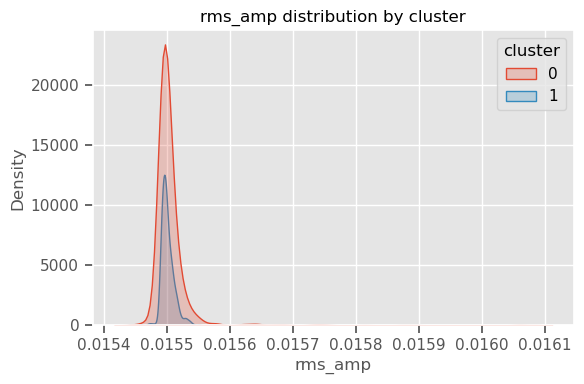

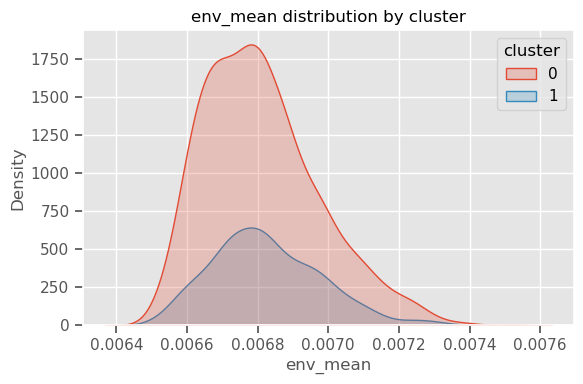

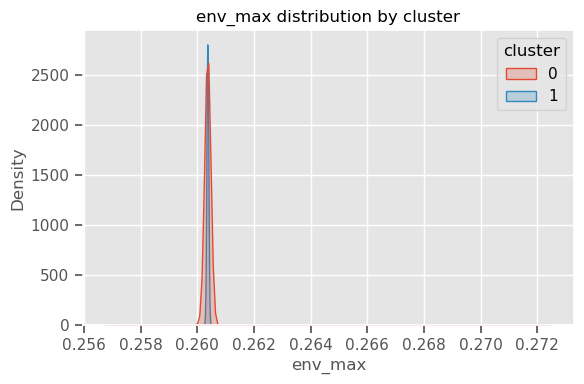

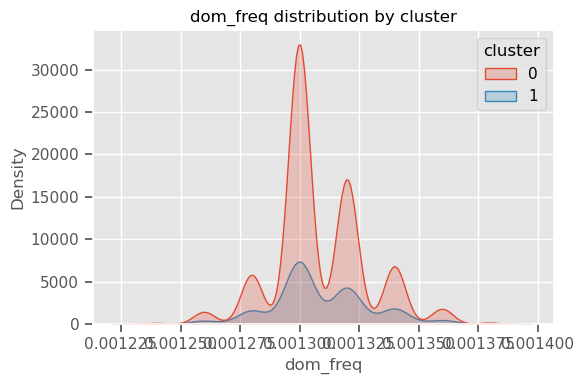

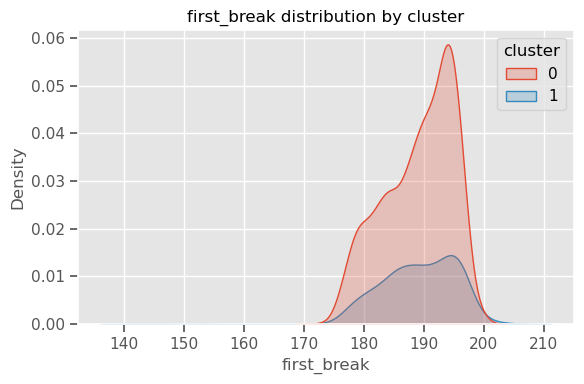

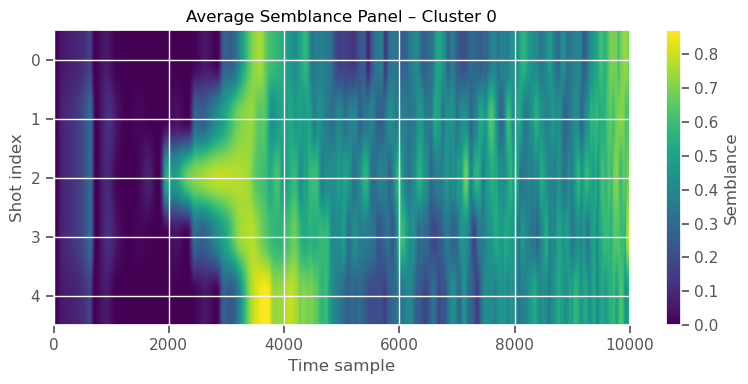

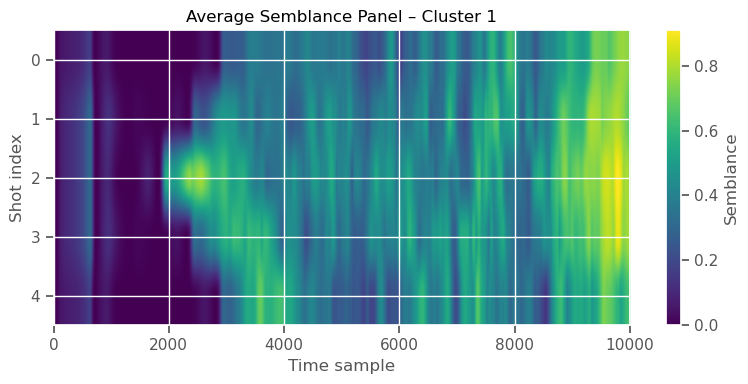

In [13]:
records = []
for _, row in df_clusters.iterrows():
    sid = row['sample_id']
    cluster = row[CLUSTER_COL]
    gather = load_gather(sid)
    m, s, r, e_mean, e_max, dfreq = compute_metrics(gather)
    fb = pick_first_breaks(gather)
    records.append({
        'sample_id': sid,
        'cluster':   cluster,
        'mean_amp':  m,
        'std_amp':   s,
        'rms_amp':   r,
        'env_mean':  e_mean,
        'env_max':   e_max,
        'dom_freq':  dfreq,
        'first_break': fb
    })

metrics_df = pd.DataFrame(records)

# -- Plot per-cluster distributions --
for feat in ['mean_amp','std_amp','rms_amp','env_mean','env_max','dom_freq','first_break']:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=metrics_df, x=feat, hue='cluster', fill=True)
    plt.title(f'{feat} distribution by cluster')
    plt.tight_layout()
    plt.show()

# -- Semblance panels per cluster --
for c in sorted(metrics_df['cluster'].unique()):
    sids = metrics_df[metrics_df['cluster']==c]['sample_id'].tolist()[:10]
    accum = None
    for sid in sids:
        sem = compute_semblance_panel(load_gather(sid))
        accum = sem if accum is None else accum + sem
    avg_sem = accum / len(sids)
    plt.figure(figsize=(8,4))
    plt.imshow(avg_sem, aspect='auto', cmap='viridis')
    plt.title(f'Average Semblance Panel – Cluster {c}')
    plt.xlabel('Time sample')
    plt.ylabel('Shot index')
    plt.colorbar(label='Semblance')
    plt.tight_layout()
    plt.show()

## Sanity Check Summary

After computing and comparing key gather metrics (mean_amp, std_amp, rms_amp, env_mean, env_max, dom_freq, first_break) for each DBSCAN+UMAP cluster, we find:

- **Nearly identical distributions** for every metric—peaks and spreads line up almost perfectly.
- The only visible difference is **density** (cluster 0 has more samples, so its KDE curve is taller), not a shift in the underlying values.

This tells us that, aside from sample count, the two clusters do **not** represent distinct geophysical regimes in terms of these basic summary statistics.

---

### Implications & Next Steps

1. **Discard hard cluster labels** as features—they don’t capture meaningful differences beyond point density.  
2. **Leverage UMAP embeddings directly** as continuous inputs to downstream models (include `umap1` and `umap2` as extra channels to the CNN or as features in a baseline).
3. If we still need stratification, consider **binning UMAP1** (or another continuous descriptor) into quartiles rather than using discrete cluster IDs.  
4. Continue with **feature engineering** and **model prototyping**, integrating UMAP coordinates and hand-crafted metrics, and proceed to build our inversion network.


In [14]:
to_keep = ['sample_id','split'] + [c for c in df.columns
                                   if c.startswith(('mean_amp','std_amp','rms_amp',
                                                     'env_mean','env_max','dom_freq',
                                                     'first_break','umap'))]
final_df = df[to_keep].copy()

OUT_PATH = '../data/processed/final_features.csv'
final_df.to_csv(OUT_PATH, index=False)
print(f"Saved final features to {OUT_PATH}")

Saved final features to ../data/processed/final_features.csv
